## Define Paths and File Catalogue

In [59]:
from pathlib import Path
import pandas as pd
import sys, json, subprocess

PROJECT_ROOT = Path('..').resolve()

DATA_PATH = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'
SIGNAL_COL = 'ERKKTR_ratio'
CSV_ROOT = PROJECT_ROOT / 'outputs'

meta = pd.read_csv(META_PATH, encoding='utf-8-sig').rename(columns={'Site': 'Image_Metadata_Site'})
meta['Image_Metadata_Site'] = meta['Image_Metadata_Site'].astype(int)
site_to_mutation = meta.set_index('Image_Metadata_Site')['Mutation'].to_dict()

print(site_to_mutation)

{1: 'WT', 2: 'WT', 3: 'WT', 4: 'WT', 5: 'AKT1_E17K', 6: 'AKT1_E17K', 7: 'AKT1_E17K', 8: 'AKT1_E17K', 9: 'PIK3CA_E545K', 10: 'PIK3CA_E545K', 11: 'PIK3CA_E545K', 12: 'PIK3CA_E545K', 13: 'PIK3CA_H1047R', 14: 'PIK3CA_H1047R', 15: 'PIK3CA_H1047R', 16: 'PIK3CA_H1047R', 17: 'PTEN_del', 18: 'PTEN_del', 19: 'PTEN_del', 20: 'PTEN_del', 21: 'PTEN_del', 22: 'PTEN_del', 23: 'PTEN_del', 24: 'PTEN_del', 25: 'ErbB2', 26: 'ErbB2', 27: 'ErbB2', 28: 'ErbB2'}


## Prepare data

In [ ]:
def run_single_block(exp, site, signal, radius=60, window=3, quantile=0.9, outdir_tag=None):
    outdir = OUTPUT_ROOT / (outdir_tag or f'exp_{exp}_site_{site}_{signal}')
    # Reuse existing output if already computed with default tag
    summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    if summary_path.exists() and outdir_tag is None:
        with open(summary_path) as f:
            return json.load(f)
    cmd = [
        sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
        '--exp-id', str(exp), '--site-id', str(site),
        '--signal-col', signal,
        '--spatial-radius', str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile', str(quantile),
        '--output-dir', str(OUTPUT_ROOT),
    ]
    subprocess.run(cmd, capture_output=True)
    with open(summary_path) as f:
        return json.load(f)

In [ ]:
# Selected cell lines and corresponding site IDs
selected = {
    "WT": 1,
    "AKT1_E17K": 5,
    "PTEN_del": 17
}

# Store paths to node-level output files
nodes_files = {}

# Store summary statistics for each mutation
all_summaries = []

for mut in selected:

    print(f"\nRunning {mut}")

    # Get site ID for current mutation
    site = selected[mut]

    print(f"  Site {site}...", end=" ")

    # Run propagation analysis for one experiment-site block
    summary = run_single_block(
        exp=1,
        site=site,
        signal=SIGNAL_COL
    )

    # Save summary statistics
    all_summaries.append(summary)

    # Save path to nodes table for later lag analysis
    nodes_files[mut] = (
        OUTPUT_ROOT /
        f'exp_{1}_site_{site}_{SIGNAL_COL}' /
        "nodes.csv.gz"
    )

    print("done")


Running WT
  Site 1... done

Running AKT1_E17K
  Site 5... done

Running PTEN_del
  Site 17... done


In [62]:
def construct_columns(nodes, MAX_LAG):
    nodes = nodes.sort_values(['track_id', 'Image_Metadata_T']).reset_index(drop=True)

    # MAX_LAG = 6

    for tau in range(1, MAX_LAG + 1):
        # shift(tau) within each track: row at position i gets the value from i-tau
        # i.e. "neighbour jump status tau frames ago"
        nodes[f'lagged_exposure_{tau}'] = (
            nodes.groupby('track_id')['neighbor_jump_now']
                .shift(tau)
                .fillna(False)
                .astype(bool)
        )

    return nodes

## Compute RR

In [63]:
def compute_rr(nodes, MAX_LAG):
    results = []

    for tau in range(MAX_LAG + 1):
        col = 'neighbor_jump_now' if tau == 0 else f'lagged_exposure_{tau}'
        exposed   = nodes[nodes[col] == True]
        unexposed = nodes[nodes[col] == False]

        p_exp   = exposed['future_self_jump'].mean()
        p_unexp = unexposed['future_self_jump'].mean()
        rr = p_exp / p_unexp if p_unexp > 0 else np.nan
        rd = p_exp - p_unexp

        results.append({
            'τ (frames)': tau,
            'τ (min)':    tau * 5,
            'n_exposed':  len(exposed),
            'p_exp':      round(p_exp, 4),
            'p_unexp':    round(p_unexp, 4),
            'RD':         round(rd, 4),
            'RR':         round(rr, 4),
        })

    df_lag = pd.DataFrame(results).set_index('τ (frames)')
    return df_lag

In [ ]:
# Store lagged RR tables for each mutation
final_df = {}

# Maximum lag value (0–6 frames)
MAX_LAG = 6

for mutation in nodes_files:

    # Load node-level propagation table
    file = pd.read_csv(nodes_files[mutation])

    # Create lagged exposure columns
    nodes = construct_columns(file, MAX_LAG)

    # Compute RR(τ) for all lag values
    df_lag = compute_rr(nodes, MAX_LAG)

    # Save results for current mutation
    final_df[mutation] = df_lag

In [65]:
import pandas as pd

df_all = pd.concat(
    [
        final_df["WT"].assign(mutation="WT"),
        final_df["AKT1_E17K"].assign(mutation="AKT1_E17K"),
        final_df["PTEN_del"].assign(mutation="PTEN_del"),
    ],
    ignore_index=True
)

print(df_all)

    τ (min)  n_exposed   p_exp  p_unexp      RD      RR   mutation
0         0     146620  0.1315   0.0749  0.0566  1.7558         WT
1         5     145714  0.1284   0.0772  0.0513  1.6640         WT
2        10     144813  0.1248   0.0799  0.0450  1.5627         WT
3        15     143980  0.1206   0.0829  0.0377  1.4549         WT
4        20     143194  0.1169   0.0856  0.0313  1.3661         WT
5        25     142405  0.1136   0.0878  0.0258  1.2940         WT
6        30     141705  0.1108   0.0898  0.0210  1.2337         WT
7         0     224573  0.1553   0.0964  0.0589  1.6109  AKT1_E17K
8         5     223505  0.1538   0.0981  0.0558  1.5684  AKT1_E17K
9        10     222404  0.1529   0.0993  0.0537  1.5405  AKT1_E17K
10       15     221299  0.1520   0.1004  0.0515  1.5132  AKT1_E17K
11       20     220110  0.1514   0.1013  0.0501  1.4943  AKT1_E17K
12       25     218904  0.1507   0.1022  0.0485  1.4744  AKT1_E17K
13       30     217636  0.1499   0.1032  0.0467  1.4523  AKT1_

## Line plot:

    τ (min)  n_exposed   p_exp  p_unexp      RD      RR   mutation
7         0     224573  0.1553   0.0964  0.0589  1.6109  AKT1_E17K
14        0      56325  0.1274   0.0810  0.0464  1.5731   PTEN_del
0         0     146620  0.1315   0.0749  0.0566  1.7558         WT


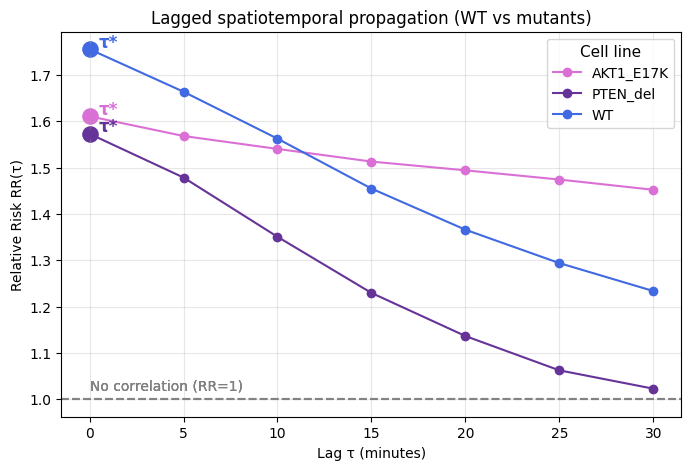

In [68]:
tau_star_df = df_all.loc[
    df_all.groupby("mutation")["RR"].idxmax()
].copy()

print(tau_star_df)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

color_map = {
    "WT": "royalblue",       # blue
    "AKT1_E17K": "orchid",   # pink
    "PTEN_del": "rebeccapurple" # purple
}

for mut, sub in df_all.groupby("mutation"):

    color = color_map.get(mut,"gray")

    plt.plot(
        sub["τ (min)"],
        sub["RR"],
        marker="o",
        label=mut,
        color=color
    )

for _, row in tau_star_df.iterrows():

    color = color_map.get(row["mutation"], "gray")
    
    plt.scatter(
        row["τ (min)"],
        row["RR"],
        s=120,
        color=color
    )

    plt.text(
        row["τ (min)"] + 0.5, 
        row["RR"] + 0.005,    
        f"τ*",
        fontsize=12,
        fontweight="bold",
        color=color
    )

    plt.axhline(y=1, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
    plt.text(
        0,
        1.02, 
        "No correlation (RR=1)", 
        color="gray", 
        fontsize=10, 
        ha="left"
    )

plt.xlabel("Lag τ (minutes)")
plt.ylabel("Relative Risk RR(τ)")
plt.title("Lagged spatiotemporal propagation (WT vs mutants)")
plt.legend(title="Cell line", title_fontsize=11, fontsize=10, loc="upper right")
plt.grid(True, alpha=0.3)
plt.savefig(CSV_ROOT / "lagged_exposure_table.png")
plt.show()

## Summary table

In [67]:
# 1. Identify the row indices with the maximum Relative Risk (RR) for each mutation
idx = tau_star_df.groupby('mutation')['RR'].idxmax()

# 2. Extract these rows and select specific columns for the summary
summary_tau = tau_star_df.loc[idx, ['mutation', 'τ (min)', 'RR']]

# 3. Rename columns according to the assignment requirements
summary_tau = summary_tau.rename(columns={
    'τ (min)': 'optimal_lag_tau_star',
    'RR': 'max_RR'
})

# 4. Display the resulting summary table
print("Summary table:")
print(summary_tau.to_string(index=False))

# 5. Optional: Save the summary results to a CSV file
summary_tau.to_csv(CSV_ROOT / "lagged_exposure_table.csv", index=False)

Summary table:
 mutation  optimal_lag_tau_star  max_RR
AKT1_E17K                     0  1.6109
 PTEN_del                     0  1.5731
       WT                     0  1.7558
